# **Arithmetic operations**
## Image Processing and Computer Vision


Arithmetic operations such as addition, subtraction and bitwise operations (AND or, NOT, XOR) are fundamental techniques in image processing.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Subtraction

There are several ways to code the subtraction in Python

### Python function

When we perform subtractions with Python, we have to consider that the images are read as **numpy array** (with **uint8** for data type)

In [2]:
IMG_PATH_SUB = "./img/mario-game.png"

img_mario = cv2.imread(IMG_PATH_SUB)
img_mario = cv2.cvtColor(img_mario, cv2.COLOR_BGR2RGB)
print("Type array:",type(img_mario))
print("Data type:", img_mario.dtype)

Type array: <class 'numpy.ndarray'>
Data type: uint8


Due to the fact I have to deal with uint8 when I perform the subtraction 20-10 I get 246. img1 - img2 is performed in **uint8 arithmetic**, which **wraps around on** negatives instead of going negative.

In [3]:
img_test_1 = np.array([10],dtype=np.uint8) #Array numpy uint8
img_test_2 = np.array([20],dtype=np.uint8) #Array numpy uint8

print(img_test_1 - img_test_2)


[246]


In [4]:
#Simple method
#It works well when the images are uint8 (use wrap around).
#Otherwise with uint16 we could have negative values
"""
def subtraction(img1, img2):
    return img1-img2 #naive method
"""

#Second version: deal with negative numbers
#In this case, I wrap around when there is a possible "overflow".
#When the images are uint8, the np.clip is useless because the values are never less than 0 and more than 255.
# 1) Compute the difference
#   a) if uint8 (images) uses wrap around
#   b) if uint16 (or int16, ...) negative numbers can appear
# 2) Remove negative numbers and substitute with 0 (or 255 if pixel > 255 ) using np.clip
def subtraction(img1, img2):
    return np.clip(img1 - img2, 0,255)

#Third version: more sophisticated
#In this case, indipendently of the data type, we perform the following steps:
# 1) Convert to int16
# 2) Compute the difference
# 3) Remove negative numbers and substitute with 0 (or 255 if pixel > 255 ) using np.clip
# 4) Convert to uint8
"""    
def subtraction(img1, img2):
    diff = img1.astype(np.int16) - img2.astype(np.int16) #With int16 I can have negative numbers (and don't risk to wrap around values)
    return np.clip(diff, 0, 255).astype(np.uint8)
"""

"    \ndef subtraction(img1, img2):\n    diff = img1.astype(np.int16) - img2.astype(np.int16) #With int16 I can have negative numbers (and don't risk to wrap around values)\n    return np.clip(diff, 0, 255).astype(np.uint8)\n"

Which is the better solution? The answer is that there is no “correct way” — it simply depends on how you are manipulating your pixels and what you want the desired results to be.

However, be sure to keep in mind that there is a difference between OpenCV and NumPy addition. NumPy will perform modulus arithmetic and “wrap around.” On the other hand, OpenCV will perform clipping and ensure pixel values never fall outside the range [0, 255]. Similar for subtraction

In the following cell, I have shown why is important to use np.clip when the data type **is not uint8**. We could have negative pixels.

In [5]:
img1 = np.array([[10,10], 
                 [20,20]])

img2 = np.array([[20,20],
                 [20,10]])

res = img1 - img2
res_clip = np.clip(img1 - img2, 0,255)

print("Normal subtraction")
print(res, end = "\n\n")

print("Subtraction with clip")
print(res_clip)

Normal subtraction
[[-10 -10]
 [  0  10]]

Subtraction with clip
[[ 0  0]
 [ 0 10]]


Let's test the algorithm

In [6]:
IMG_PATH_SUB = "./img/mario-game.png"
IMG_PATH_SUB_BACK = "./img/mario-back.png"

Text(0.5, 1.0, 'Result')

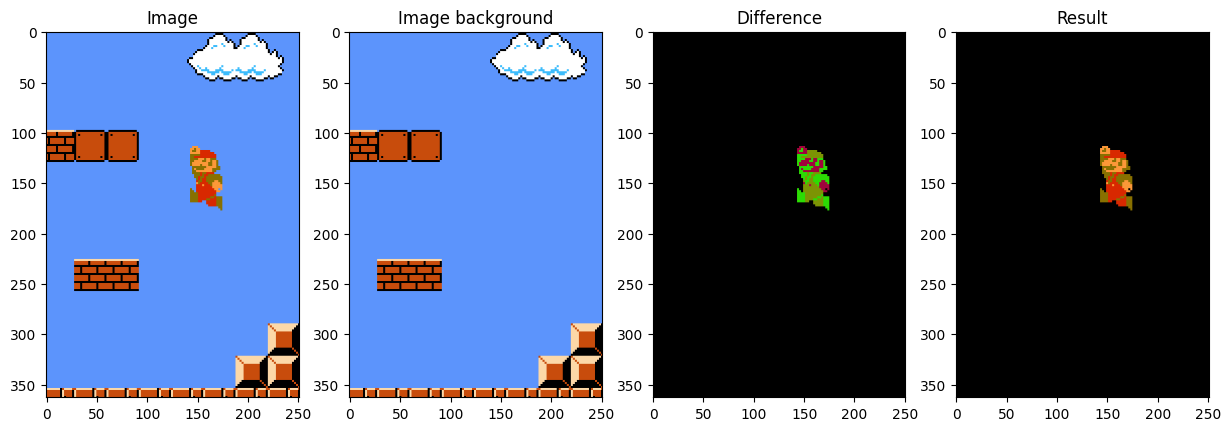

In [7]:
img_mario = cv2.imread(IMG_PATH_SUB)
img_mario = cv2.cvtColor(img_mario, cv2.COLOR_BGR2RGB)

img_mario_back = cv2.imread(IMG_PATH_SUB_BACK)
img_mario_back = cv2.cvtColor(img_mario_back, cv2.COLOR_BGR2RGB)

# 1) Compute the difference
diff_py = subtraction(img_mario, img_mario_back)

# 2) Create a mask using True/False values 
mask = diff_py!=0

# 3) Create a zero numpy array with the same dimension of the image
res_py = np.zeros_like(img_mario)

# 4) Copy the original pixes from the image to the final result image
res_py[mask] = img_mario[mask]


plt.figure(figsize=(15,15))

plt.subplot(1,4,1)
plt.imshow(img_mario)
plt.title("Image")

plt.subplot(1,4,2)
plt.imshow(img_mario_back)
plt.title("Image background")

plt.subplot(1,4,3)
plt.imshow(diff_py)
plt.title("Difference")

plt.subplot(1,4,4)
plt.imshow(res_py)
plt.title("Result")

### OpenCV function

Syntax:
- cv.subtract(src1, src2[, dst[, mask[, dtype]]]	) -> dst

How does it calculate the **substraction with images**:
- dst(I) = saturate( src1(I) - src2(I) )   if mask(I) $\neq$ 0

Parameters: 
- **src1**, **src2**: input images
- **dst**: output images
- **mask**: optional operation mask; this is an 8-bit single channel array that specifies elements of the output array to be changed.
- **dtype**: optional depth of the output array

Example:

In [8]:
img1 = np.array([[10,10], 
                 [20,20]])

img2 = np.array([[20,20],
                 [20,10]])

res = cv2.subtract(img1, img2,dtype=cv2.CV_8U)

print(res)

[[ 0  0]
 [ 0 10]]


In [9]:
IMG_PATH_SUB = "./img/mario-game.png"
IMG_PATH_SUB_BACK = "./img/mario-back.png"

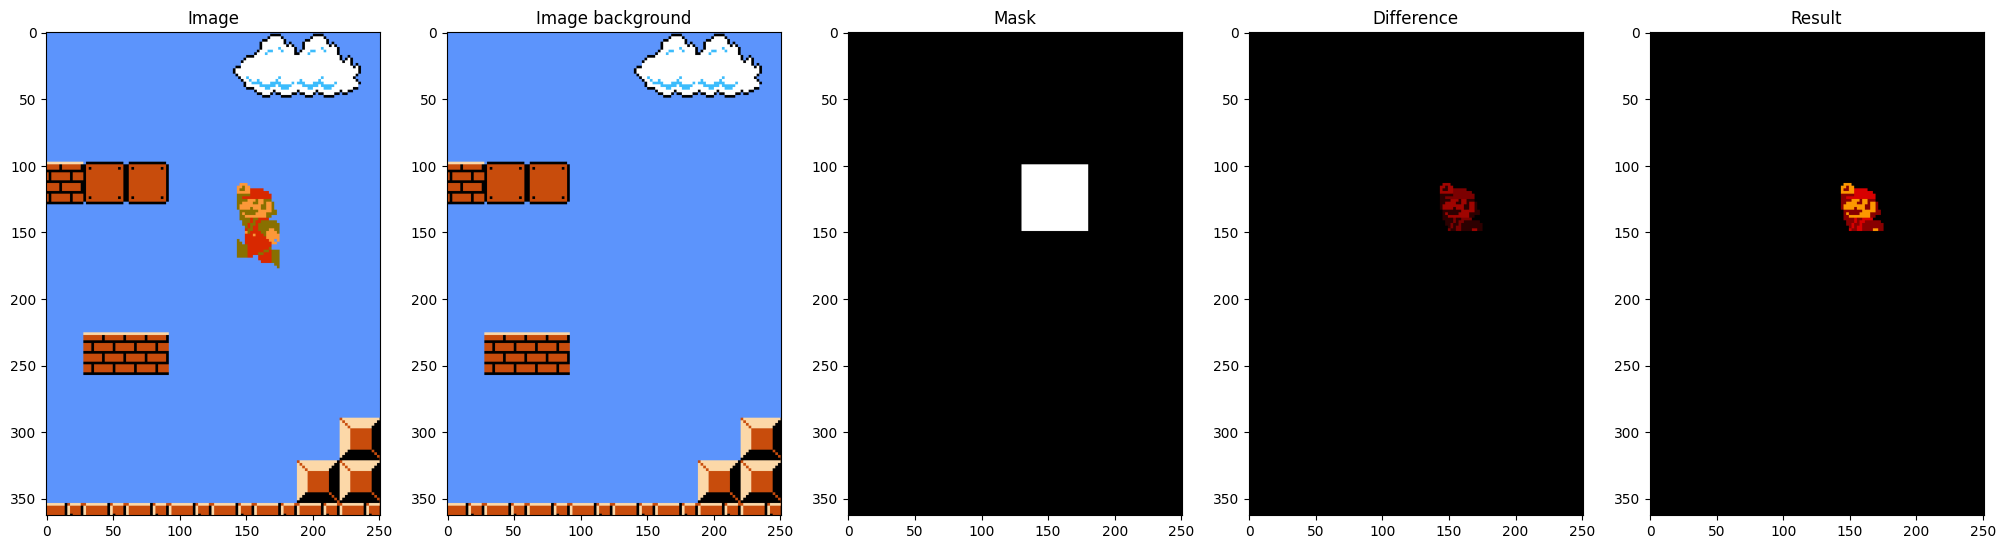

In [23]:
img_mario = cv2.imread(IMG_PATH_SUB)
img_mario = cv2.cvtColor(img_mario, cv2.COLOR_BGR2RGB)

img_mario_back = cv2.imread(IMG_PATH_SUB_BACK)
img_mario_back = cv2.cvtColor(img_mario_back, cv2.COLOR_BGR2RGB)

# Create the black images for the final result
res = np.zeros_like(img_mario)

# 1) Compute the mask: create a mask using 255/0 values 
h, w = img_mario.shape[:2]
mask_cv = np.zeros((h, w), dtype=np.uint8)
mask_cv[100:150, 130:180] = 255

# 2) Compute difference
diff_cv = cv2.subtract(img_mario, img_mario_back, mask = mask_cv, dtype=cv2.CV_8U)

#diff = diff.astype(np.uint8) 
# 3) Create the mask with True/False values
mask = diff_cv!=0

# 4) #Compute the final result
res_cv = np.zeros_like(img_mario)
res_cv[mask] = img_mario[mask]


plt.figure(figsize=(25,25))

plt.subplot(1,5,1)
plt.imshow(img_mario)
plt.title("Image")


plt.subplot(1,5,2)
plt.imshow(img_mario_back)
plt.title("Image background")

plt.subplot(1,5,3)
plt.imshow(mask_cv, cmap = "gray")
plt.title("Mask")


plt.subplot(1,5,4)
plt.imshow(diff_cv)
plt.title("Difference")

plt.subplot(1,5,5)
plt.imshow(res_cv)
plt.title("Result")

plt.show()


There are some difference between the result of the python function method and the OpenCV method. The overall gaol is achieved but we can study more these differences.

### Comparison

Let's study more deeply the results

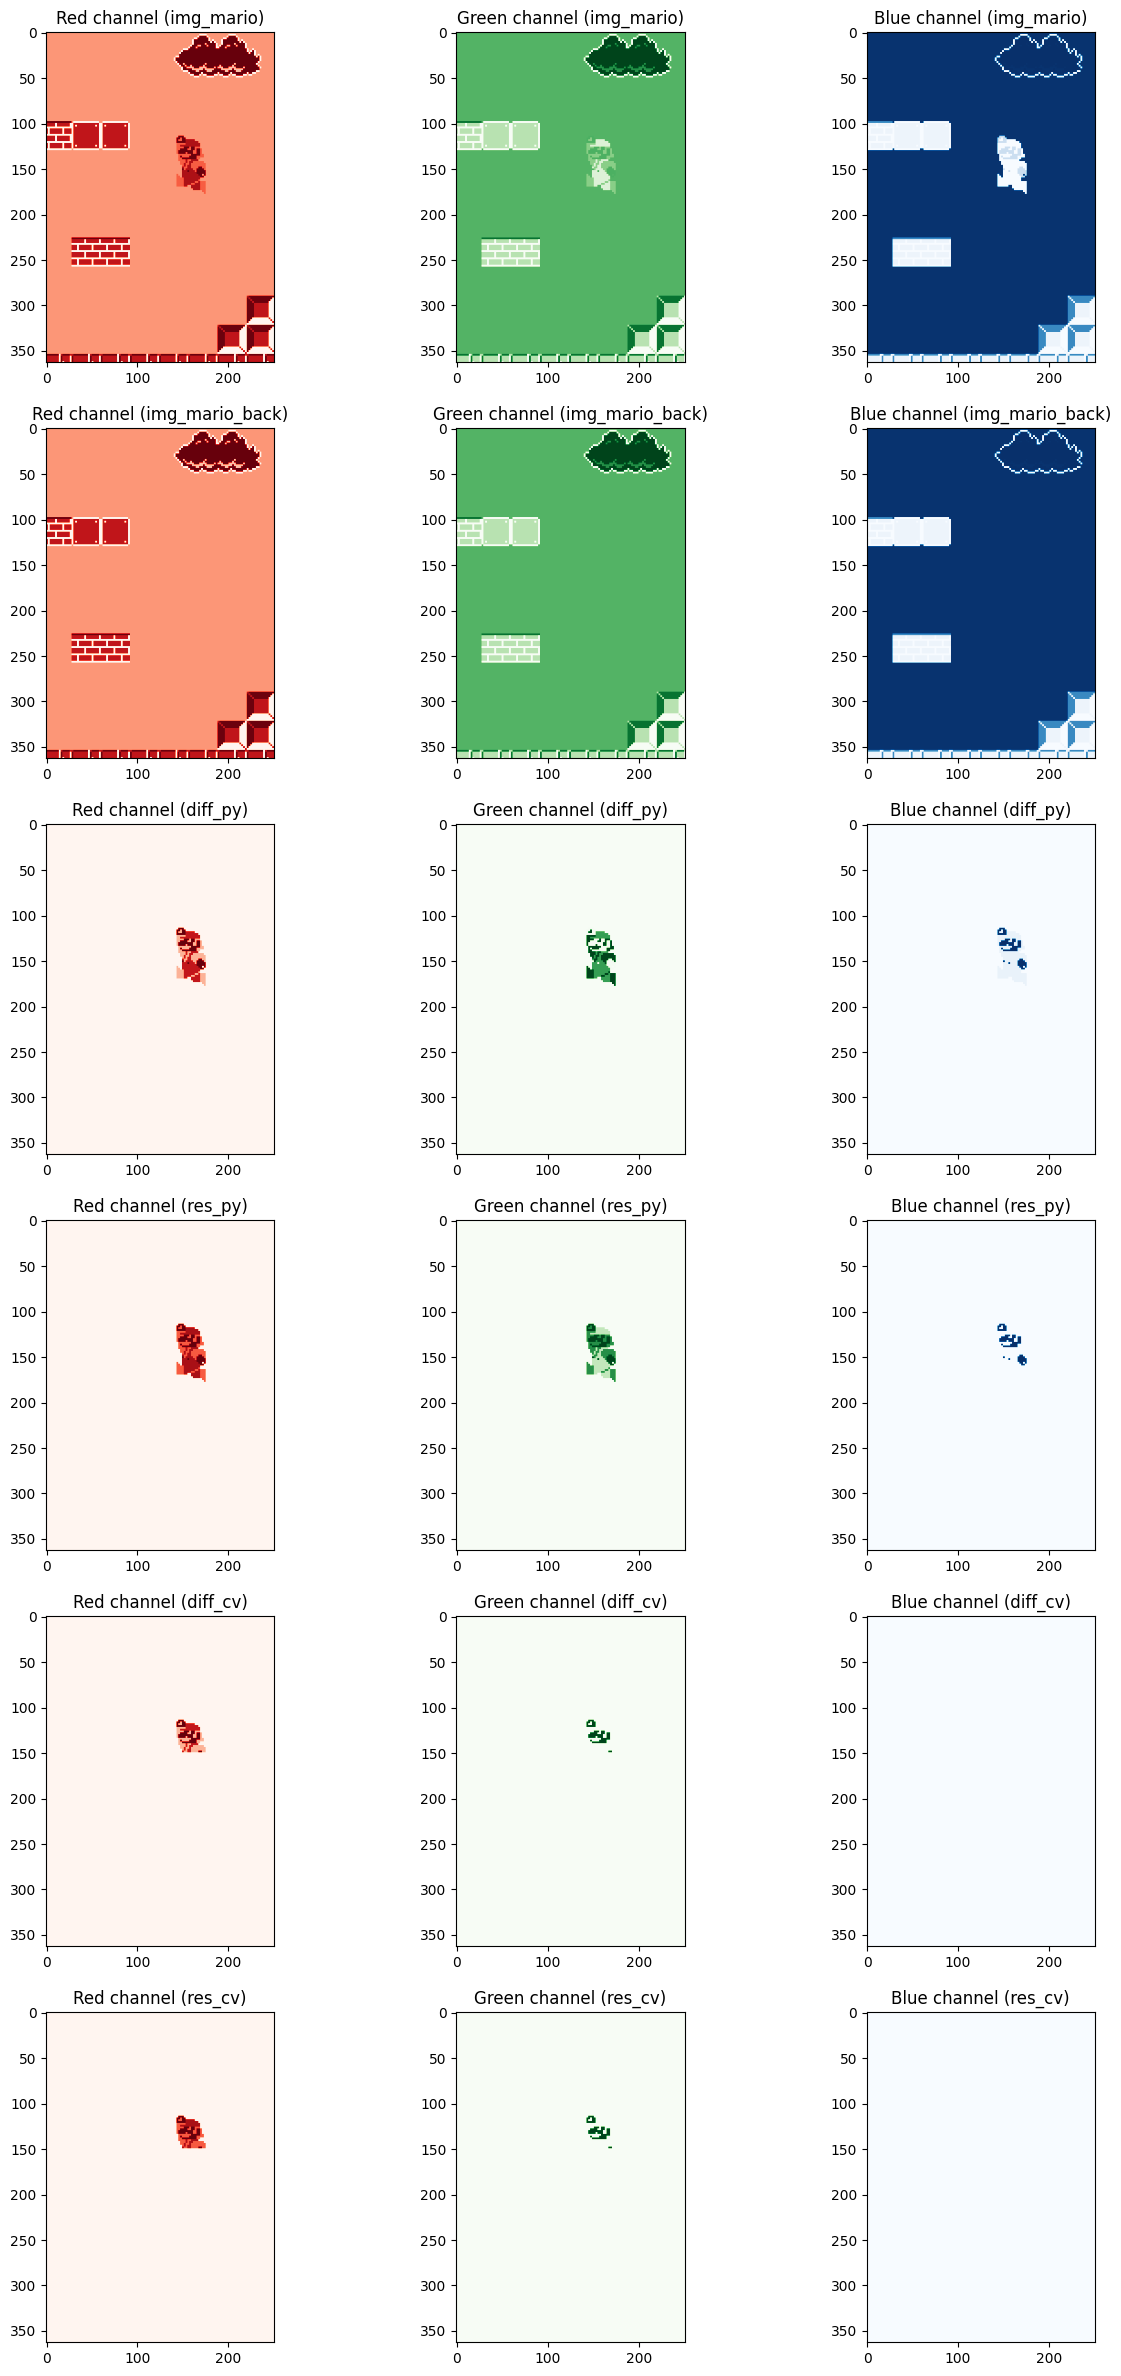

In [22]:
plt.figure(figsize=(15,30))

i = 1

list_img = [
    ("img_mario", img_mario),
    ("img_mario_back", img_mario_back),
    ("diff_py", diff_py),
    ("res_py", res_py),
    ("diff_cv", diff_cv),
    ("res_cv", res_cv)
]

for title, img in list_img:
    r, g, b = cv2.split(img)
    rows = len(list_img)

    plt.subplot(rows,3,i)
    i+=1
    plt.imshow(r, cmap="Reds")
    plt.title("Red channel (" + title+ ")")

    plt.subplot(rows,3,i)
    i+=1
    plt.imshow(g, cmap="Greens")
    plt.title("Green channel (" + title + ")")

    plt.subplot(rows,3,i)
    i+=1
    plt.imshow(b, cmap="Blues")
    plt.title("Blue channel (" + title + ")")





As it can be noticed from the previous plots, the blue channel of the OpenCV method is empty due to the way we perform the calculation.

In [28]:
from prettytable import PrettyTable


data = [
  (str((135,160)), img_mario[135,160,2], img_mario_back[135,160,2], diff_py[135,160,2], res_py[135,160,2], diff_cv[135,160,2], res_cv[140,160,2]),
]
table_zoom = PrettyTable(["Example", "img_mario", "img_mario_back", "blue_ch diff_py", "blue_ch res_py", "blue_ch diff_cv", "blue_ch res_cv"])

#Compute mean and stddve of homogeneous images
for row_label, img_mario_px, img_mario_back_px, b_diff_py_px, b_res_py_px, b_diff_cv_px, b_res_cv_px in data:
  table_zoom.add_row([row_label, img_mario_px, img_mario_back_px, b_diff_py_px, b_res_py_px, b_diff_cv_px, b_res_cv_px])


print(table_zoom)


+------------+-----------+----------------+-----------------+----------------+-----------------+----------------+
|  Example   | img_mario | img_mario_back | blue_ch diff_py | blue_ch res_py | blue_ch diff_cv | blue_ch res_cv |
+------------+-----------+----------------+-----------------+----------------+-----------------+----------------+
| (135, 160) |     56    |      252       |        60       |       56       |        0        |       0        |
+------------+-----------+----------------+-----------------+----------------+-----------------+----------------+


### Conclusion

As I have written before, there isn't an absoulte better solution. Depends on the taks. In these experiments, the goal is to remove the background and just focus on mario character. In this case it's preferable to use the second version of the python function because when pixel1 - pixel2 is performed and the result is negative, the wrap around mechanism assigns a values $\neq$ 0. In this way, when I use the result as a mask to get the original pixel value of mario, then those pixels (that should be theoretically negative) will have a positive value (so in the mask are considered as a True value) and the original pixel will be retrieved. Otherwise if I clip the values between 0 and 255 (like in np.subtract), all the negative numbers will be substitute with zero and when I will use those pixels in the mask, they will not let me retrieve the origianl pixel of mario. This effect doesn't happen strongly in these examples that I have shown and it is not visible to the human eye but theoretically some pixels could miss in the final result

## Addition

## Bitwise operation